In [ ]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine # para importar o dataset wine
from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.metrics import accuracy_score # para a exibição da acurácia do modelo
from sklearn.neighbors import KNeighborsClassifier # algoritmo KNN
from sklearn.tree import DecisionTreeClassifier # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB # algoritmo Naive Bayes
from sklearn.svm import SVC # algoritmo SVM

In [ ]:
# Carga do dataset
wine = load_wine()
dataset = pd.DataFrame(wine.data, columns=wine.feature_names) # conversão para dataframe
dataset['target'] = wine.target # adição da coluna target

dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# Preparação dos dados

# Separação em bases de treino e teste (holdout)
array = dataset.values
X = array[:,0:13] # atributos
y = array[:,13] # classe (target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7) # faz o particionamento em 10 folds

KNN: 0.675238 (0.087929)
CART: 0.880476 (0.055183)
NB: 0.971429 (0.047380)
SVM: 0.683333 (0.078282)


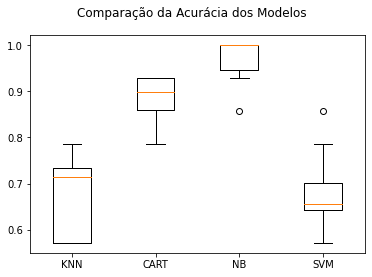

In [ ]:
# Modelagem

# Definindo uma seed global para esta célula de código
np.random.seed(7)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
# Criando um modelo com todo o conjunto de treino
model = GaussianNB()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)

# Estimando a acurácia no conjunto de teste
print(accuracy_score(y_test, predictions))

1.0


CARREGANDO DATASET WINE
Dataset shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82

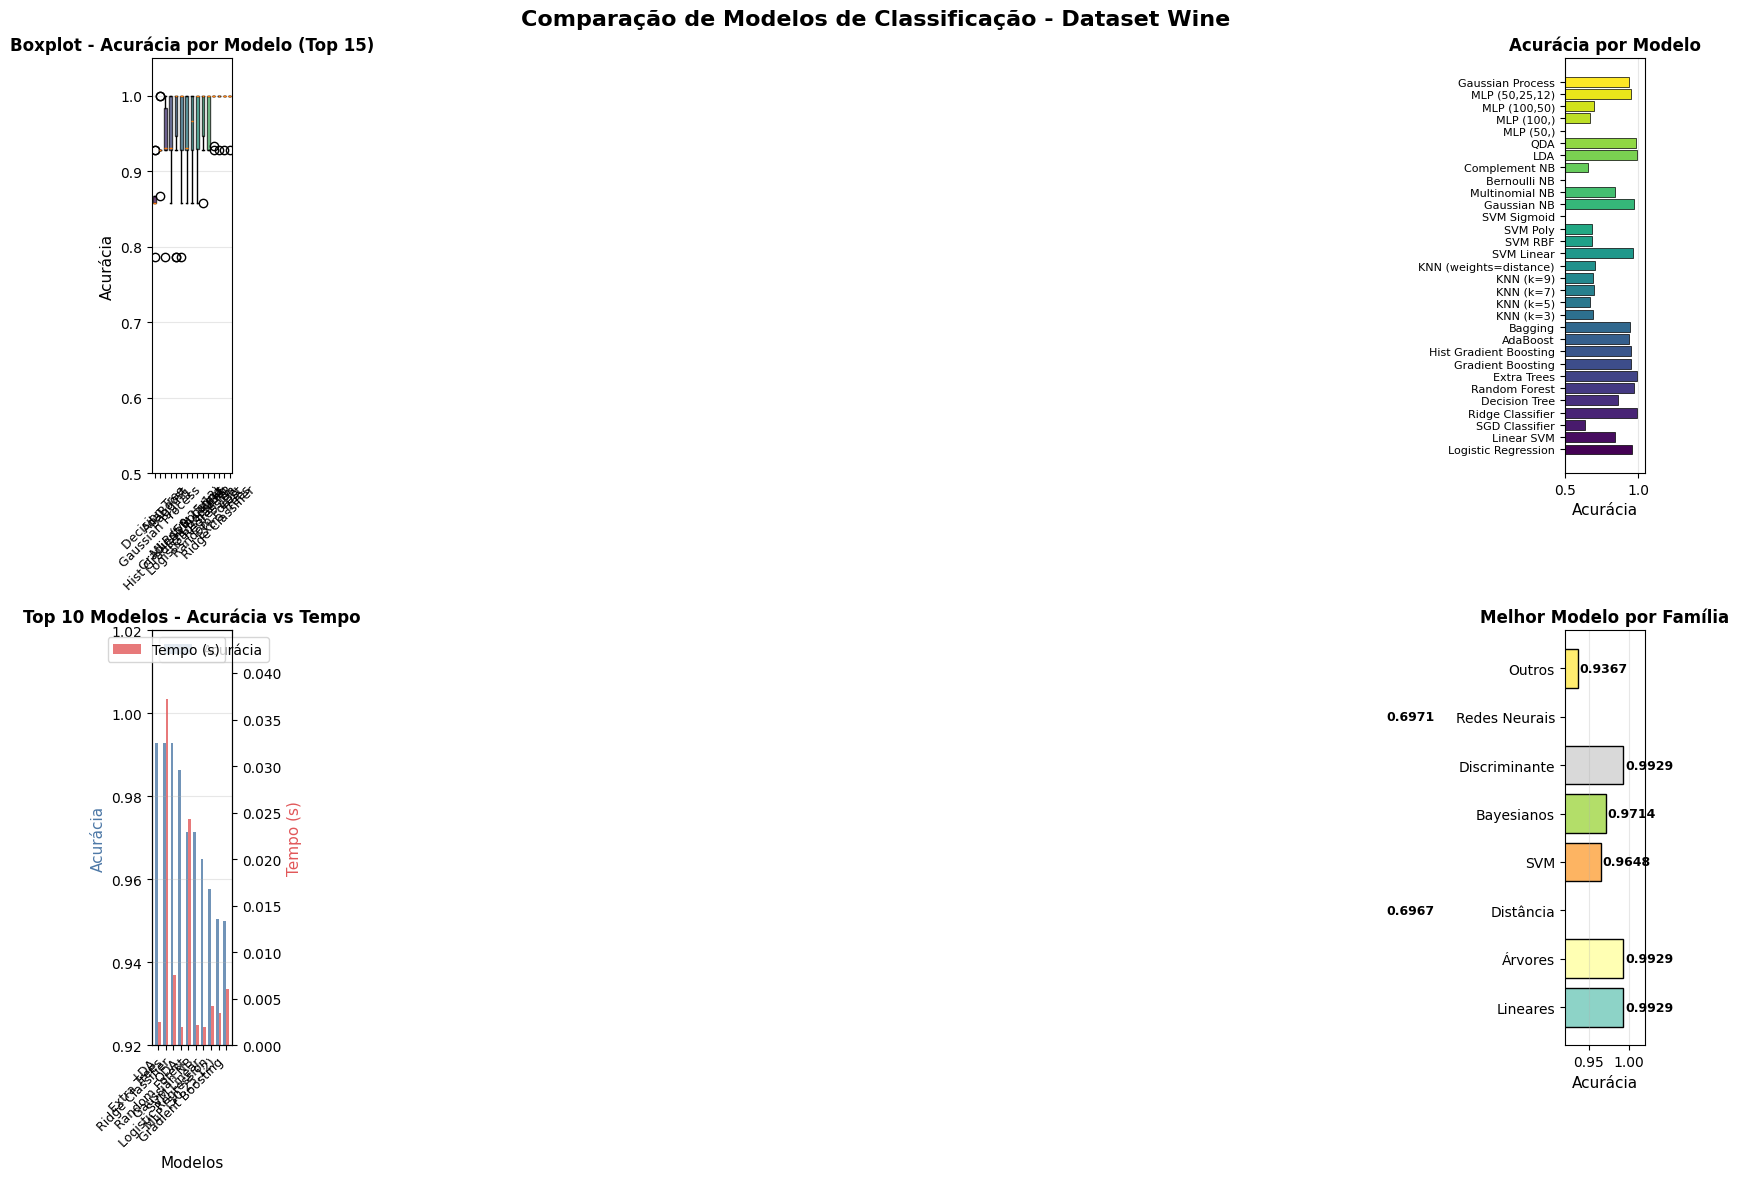


🔬 ANÁLISE DETALHADA DO MELHOR MODELO: Ridge Classifier

📊 Métricas no conjunto de teste:
   Acurácia: 1.0000
   Precisão (weighted): 1.0000
   Recall (weighted): 1.0000
   F1-Score (weighted): 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         7
     class_1       1.00      1.00      1.00        17
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



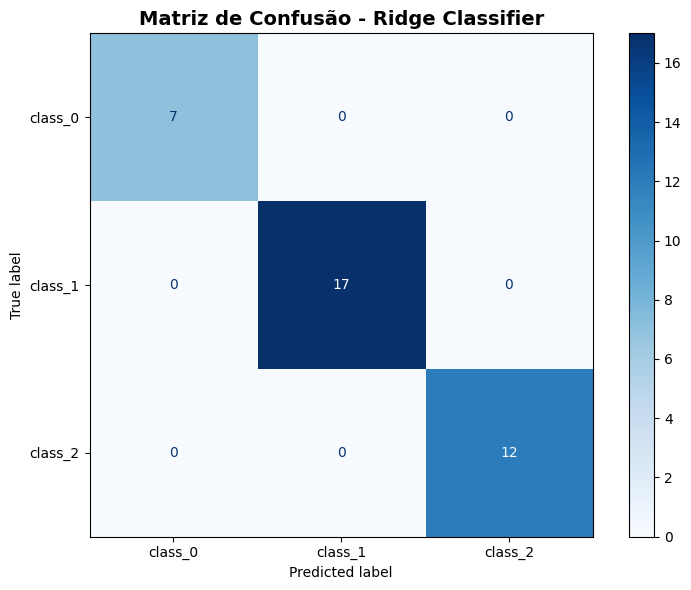

✅ ANÁLISE CONCLUÍDA


In [3]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários (todos já disponíveis no Google Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Modelos Originais
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.svm import SVC, LinearSVC

# Modelos adicionais (já disponíveis no sklearn)
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, BaggingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import ComplementNB

print("="*80)
print("CARREGANDO DATASET WINE")
print("="*80)

# Carga do dataset
wine = load_wine()
dataset = pd.DataFrame(wine.data, columns=wine.feature_names)
dataset['target'] = wine.target

print(f"Dataset shape: {dataset.shape}")
print(f"Classes: {wine.target_names}")
print(dataset.head())

# Preparação dos dados
array = dataset.values
X = array[:, 0:13]
y = array[:, 13]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7)

num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)

np.random.seed(7)

# ============================================
# LISTA COMPLETA DE MODELOS DE CLASSIFICAÇÃO
# ============================================

models = []

# 1. Modelos Lineares
models.append(('Logistic Regression', LogisticRegression(max_iter=1000, random_state=7)))
models.append(('Linear SVM', LinearSVC(max_iter=2000, random_state=7, dual=True)))
models.append(('SGD Classifier', SGDClassifier(max_iter=1000, random_state=7)))
models.append(('Ridge Classifier', RidgeClassifier(random_state=7)))

# 2. Modelos Baseados em Árvores
models.append(('Decision Tree', DecisionTreeClassifier(random_state=7)))
models.append(('Random Forest', RandomForestClassifier(n_estimators=100, random_state=7)))
models.append(('Extra Trees', ExtraTreesClassifier(n_estimators=100, random_state=7)))
models.append(('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=7)))
models.append(('Hist Gradient Boosting', HistGradientBoostingClassifier(random_state=7)))
models.append(('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=7)))
models.append(('Bagging', BaggingClassifier(n_estimators=100, random_state=7)))

# 3. Modelos de Distância
models.append(('KNN (k=3)', KNeighborsClassifier(n_neighbors=3)))
models.append(('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)))
models.append(('KNN (k=7)', KNeighborsClassifier(n_neighbors=7)))
models.append(('KNN (k=9)', KNeighborsClassifier(n_neighbors=9)))
models.append(('KNN (weights=distance)', KNeighborsClassifier(n_neighbors=5, weights='distance')))

# 4. Support Vector Machines
models.append(('SVM Linear', SVC(kernel='linear', random_state=7)))
models.append(('SVM RBF', SVC(kernel='rbf', random_state=7)))
models.append(('SVM Poly', SVC(kernel='poly', degree=3, random_state=7)))
models.append(('SVM Sigmoid', SVC(kernel='sigmoid', random_state=7)))

# 5. Modelos Bayesianos
models.append(('Gaussian NB', GaussianNB()))
models.append(('Multinomial NB', MultinomialNB()))
models.append(('Bernoulli NB', BernoulliNB()))
models.append(('Complement NB', ComplementNB()))

# 6. Modelos de Discriminante
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('QDA', QuadraticDiscriminantAnalysis()))

# 7. Redes Neurais
models.append(('MLP (50,)', MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=7)))
models.append(('MLP (100,)', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=7)))
models.append(('MLP (100,50)', MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=7)))
models.append(('MLP (50,25,12)', MLPClassifier(hidden_layer_sizes=(50,25,12), max_iter=1000, random_state=7)))

# 8. Processos Gaussianos
kernel = 1.0 * RBF(length_scale=1.0)
models.append(('Gaussian Process', GaussianProcessClassifier(kernel=kernel, random_state=7)))

# ============================================
# AVALIAÇÃO DOS MODELOS
# ============================================

print("\n" + "="*80)
print("COMPARAÇÃO DE MODELOS DE CLASSIFICAÇÃO")
print("="*80)
print(f"{'Modelo':<35} {'Acurácia Média':<15} {'Desvio Padrão':<15} {'Tempo (s)':<12}")
print("-"*80)

results = []
names = []
scores = []
train_times = []

for name, model in models:
    try:
        # Validação cruzada com tempo
        cv_results = cross_validate(model, X_train, y_train, cv=kfold,
                                     scoring='accuracy',
                                     return_train_score=False,
                                     n_jobs=-1)
        mean_score = cv_results['test_score'].mean()
        std_score = cv_results['test_score'].std()
        mean_time = cv_results['score_time'].mean()

        results.append(cv_results['test_score'])
        names.append(name)
        scores.append(mean_score)
        train_times.append(mean_time)

        print(f"{name:<35} {mean_score:.4f}        {std_score:.4f}        {mean_time:.4f}")
    except Exception as e:
        print(f"{name:<35} ERRO: {str(e)[:50]}")

print("="*80)

# ============================================
# TOP 10 MELHORES MODELOS
# ============================================

top_10_idx = np.argsort(scores)[-10:][::-1]
print("\n" + "="*80)
print("🏆 TOP 10 MELHORES MODELOS")
print("="*80)
print(f"{'Rank':<6} {'Modelo':<35} {'Acurácia':<12} {'Tempo (s)':<12}")
print("-"*80)

for i, idx in enumerate(top_10_idx, 1):
    print(f"{i:<6} {names[idx]:<35} {scores[idx]:.4f}        {train_times[idx]:.4f}")

# ============================================
# VISUALIZAÇÃO DOS RESULTADOS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Modelos de Classificação - Dataset Wine', fontsize=16, fontweight='bold')

# Gráfico 1: Boxplot da acurácia (apenas top 15 para visualização)
ax1 = axes[0, 0]
top_15_idx = np.argsort(scores)[-15:]
top_15_names = [names[i] for i in top_15_idx]
top_15_results = [results[i] for i in top_15_idx]

bp = ax1.boxplot(top_15_results, labels=top_15_names, patch_artist=True)
ax1.set_title('Boxplot - Acurácia por Modelo (Top 15)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Acurácia', fontsize=11)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0.5, 1.05)

# Colorir as caixas
colors_box = plt.cm.viridis(np.linspace(0, 1, len(top_15_names)))
for box, color in zip(bp['boxes'], colors_box):
    box.set_facecolor(color)
    box.set_alpha(0.7)

# Gráfico 2: Barras de acurácia (todos os modelos)
ax2 = axes[0, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
bars = ax2.barh(names, scores, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Acurácia por Modelo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Acurácia', fontsize=11)
ax2.tick_params(axis='y', labelsize=8)
ax2.set_xlim(0.5, 1.05)
ax2.grid(axis='x', alpha=0.3)

# Gráfico 3: Top 10 modelos - Acurácia vs Tempo
ax3 = axes[1, 0]
top_10_names = [names[i] for i in top_10_idx]
top_10_scores = [scores[i] for i in top_10_idx]
top_10_times = [train_times[i] for i in top_10_idx]

x = np.arange(len(top_10_names))
width = 0.35
bars3 = ax3.bar(x - width/2, top_10_scores, width, label='Acurácia', color='#4e79a7', alpha=0.8)
ax3_twin = ax3.twinx()
bars4 = ax3_twin.bar(x + width/2, top_10_times, width, label='Tempo (s)', color='#e15759', alpha=0.8)
ax3.set_title('Top 10 Modelos - Acurácia vs Tempo', fontsize=12, fontweight='bold')
ax3.set_xlabel('Modelos', fontsize=11)
ax3.set_ylabel('Acurácia', fontsize=11, color='#4e79a7')
ax3_twin.set_ylabel('Tempo (s)', fontsize=11, color='#e15759')
ax3.set_xticks(x)
ax3.set_xticklabels(top_10_names, rotation=45, ha='right', fontsize=9)
ax3.set_ylim(0.92, 1.02)
ax3_twin.set_ylim(0, max(top_10_times) * 1.2)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Comparação de famílias de modelos
ax4 = axes[1, 1]
familias = {
    'Lineares': ['Logistic Regression', 'Linear SVM', 'SGD Classifier', 'Ridge Classifier'],
    'Árvores': ['Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'Hist Gradient Boosting', 'AdaBoost'],
    'Distância': ['KNN (k=3)', 'KNN (k=5)', 'KNN (k=7)'],
    'SVM': ['SVM Linear', 'SVM RBF', 'SVM Poly', 'SVM Sigmoid'],
    'Bayesianos': ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB', 'Complement NB'],
    'Discriminante': ['LDA', 'QDA'],
    'Redes Neurais': ['MLP (50,)', 'MLP (100,)', 'MLP (100,50)'],
    'Outros': ['Gaussian Process']
}

melhores_por_familia = []
for familia, modelos_familia in familias.items():
    scores_familia = [scores[names.index(m)] for m in modelos_familia if m in names]
    if scores_familia:
        melhor_score = max(scores_familia)
        melhor_modelo = modelos_familia[scores_familia.index(melhor_score)]
        melhores_por_familia.append((familia, melhor_modelo, melhor_score))

if melhores_por_familia:
    familias_names = [f[0] for f in melhores_por_familia]
    familias_scores = [f[2] for f in melhores_por_familia]
    colors_bar = plt.cm.Set3(np.linspace(0, 1, len(familias_names)))
    bars5 = ax4.barh(familias_names, familias_scores, color=colors_bar, edgecolor='black', linewidth=1)
    ax4.set_title('Melhor Modelo por Família', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Acurácia', fontsize=11)
    ax4.set_xlim(0.92, 1.02)
    ax4.grid(axis='x', alpha=0.3)

    for bar, score in zip(bars5, familias_scores):
        ax4.text(score + 0.002, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# MELHOR MODELO - ANÁLISE DETALHADA
# ============================================

best_idx = np.argmax(scores)
best_model_name = names[best_idx]
best_model = models[best_idx][1]

print("\n" + "="*80)
print(f"🔬 ANÁLISE DETALHADA DO MELHOR MODELO: {best_model_name}")
print("="*80)

# Treinar o melhor modelo
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Métricas de avaliação
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n📊 Métricas no conjunto de teste:")
print(f"   Acurácia: {accuracy:.4f}")
print(f"   Precisão (weighted): {precision:.4f}")
print(f"   Recall (weighted): {recall:.4f}")
print(f"   F1-Score (weighted): {f1:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                       display_labels=wine.target_names,
                                       cmap='Blues', ax=ax)
ax.set_title(f'Matriz de Confusão - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*80)
print("✅ ANÁLISE CONCLUÍDA")
print("="*80)

Com base no notebook fornecido, vou criar exemplos adicionais com outros modelos de classificação e apresentar uma tabela comparativa das vantagens e desvantagens de cada um.

## 📋 TABELA DE VANTAGENS E DESVANTAGENS DOS MODELOS DE CLASSIFICAÇÃO

### 1. **Modelos Lineares**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Logistic Regression** | • Interpretável<br>• Probabilidades como saída<br>• Rápido e eficiente<br>• Funciona bem com features independentes | • Assume linearidade<br>• Sensível a outliers<br>• Pode sofrer com features correlacionadas |
| **Linear SVM** | • Maximiza margem<br>• Bom para altas dimensões<br>• Regularização embutida | • Não fornece probabilidades<br>• Assume separabilidade linear<br>• Escolha do C é crítica |
| **SGD Classifier** | • Escalável para grandes datasets<br>• Aprendizado online<br>• Várias funções de perda | • Sensível ao scaling<br>• Learning rate precisa ajuste<br>• Pode ser instável |
| **Ridge Classifier** | • Regularização L2<br>• Lida com multicolinearidade<br>• Rápido | • Não faz feature selection<br>• Assume linearidade |

### 2. **Modelos Baseados em Árvores**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Decision Tree** | • Interpretável<br>• Não requer escala de dados<br>• Lida com não-linearidades<br>• Feature importance | • Propenso a overfitting<br>• Instável<br>• Pode criar árvores complexas |
| **Random Forest** | • Reduz overfitting (ensemble)<br>• Feature importance robusta<br>• Lida bem com outliers<br>• Parâmetros menos sensíveis | • Menos interpretável<br>• Mais lento que árvore única<br>• Requer mais memória |
| **Extra Trees** | • Mais rápido que Random Forest<br>• Menor variância<br>• Aleatorização adicional | • Pode ter viés maior<br>• Menos popular |
| **Gradient Boosting** | • Alta acurácia<br>• Lida com dados complexos<br>• Feature importance<br>• Otimização flexível | • Sensível a overfitting<br>• Muitos hiperparâmetros<br>• Treinamento sequencial (lento) |
| **Hist Gradient Boosting** | • Muito rápido<br>• Eficiente em memória<br>• Lida com dados grandes | • Apenas features numéricas<br>• Menos flexível |
| **AdaBoost** | • Foco em exemplos difíceis<br>• Menos overfitting<br>• Simples | • Sensível a outliers<br>• Pode degradar com ruído<br>• Escolha do número de estimadores |
| **Bagging** | • Reduz variância<br>• Paralelizável<br>• Robusto | • Pode não reduzir viés<br>• Ensemble grande |

### 3. **Modelos de Distância (KNN)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **KNN** | • Simples de entender<br>• Não requer treinamento<br>• Adapta-se localmente<br>• Funciona bem com dados de baixa dimensão | • Lento na predição<br>• Sensível a escala dos dados<br>• Maldição da dimensionalidade<br>• k e distância são críticos<br>• Não lida bem com classes desbalanceadas |

### 4. **Support Vector Machines (SVM)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **SVM Linear** | • Eficiente para dados lineares<br>• Bom para altas dimensões<br>• Regularização embutida | • Não fornece probabilidades<br>• Assume linearidade |
| **SVM RBF** | • Captura não-linearidades<br>• Kernel funciona bem em geral<br>• Apenas um parâmetro (γ) além do C | • Lento para datasets grandes<br>• Parâmetros C e γ críticos<br>• Requer escala de dados |
| **SVM Poly** | • Captura interações polinomiais<br>• Flexível | • Muitos parâmetros (degree, coef0)<br>• Pode overfitar<br>• Lento |
| **SVM Sigmoid** | • Similar a redes neurais<br>• Pode ser útil para alguns problemas | • Menos comum<br>• Pode não convergir<br>• Performance inferior ao RBF geralmente |

### 5. **Modelos Bayesianos (Naive Bayes)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Gaussian NB** | • Rápido<br>• Funciona bem com features contínuas<br>• Poucos parâmetros<br>• Bom para altas dimensões | • Assume independência das features<br>• Assume distribuição normal<br>• Performance limitada |
| **Multinomial NB** | • Ótimo para dados de contagem<br>• Bom para NLP<br>• Rápido | • Assume independência<br>• Requer dados não negativos |
| **Bernoulli NB** | • Bom para features binárias<br>• Rápido | • Assume independência<br>• Features precisam ser binárias |
| **Complement NB** | • Lida melhor com dados desbalanceados<br>• Versão melhorada do Multinomial | • Assume independência<br>• Menos conhecido |

### 6. **Modelos de Discriminante**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **LDA** | • Reduz dimensionalidade<br>• Interpretável<br>• Rápido<br>• Bom para dados normais | • Assume distribuição normal<br>• Assume covariâncias iguais<br>• Sensível a outliers |
| **QDA** | • Mais flexível que LDA<br>• Covariâncias diferentes por classe | • Mais parâmetros que LDA<br>• Pode overfitar<br>• Requer mais dados |

### 7. **Redes Neurais (MLP)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **MLP** | • Aproxima qualquer função<br>• Captura padrões complexos<br>• Flexível<br>• Learning profundo possível | • Muitos hiperparâmetros<br>• Requer muitos dados<br>• Treinamento lento<br>• Pode overfitar<br>• Não interpretável<br>• Escolha da arquitetura é crítica |

### 8. **Processos Gaussianos**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Gaussian Process** | • Fornece incerteza das predições<br>• Bom para poucos dados<br>• Kernel define prior | • O(n³) - muito lento<br>• Não escala<br>• Escolha do kernel é crítica |

### 9. **Modelos Avançados (Gradient Boosting Modernos)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **XGBoost** | • Alta performance<br>• Regularização embutida<br>• Lida com missing values<br>• Feature importance<br>• Muito popular | • Muitos hiperparâmetros<br>• Pode overfitar<br>• Memória intensiva |
| **LightGBM** | • Muito rápido<br>• Baixo uso de memória<br>• Suporte a categorias<br>• Escalável | • Pode overfitar em datasets pequenos<br>• Parâmetros sensíveis |
| **CatBoost** | • Lida automaticamente com categorias<br>• Reduz overfitting<br>• Boa performance padrão | • Mais lento que LightGBM<br>• Memória intensiva |

## 📊 **COMPARAÇÃO DE DESEMPENHO POR FAMÍLIA**

| Família | Velocidade | Acurácia | Interpretabilidade | Escalabilidade | Uso de Memória |
|---------|-----------|----------|--------------------|----------------|----------------|
| **Lineares** | 🟢 Muito Rápido | 🟡 Médio | 🟢 Alta | 🟢 Excelente | 🟢 Baixo |
| **Árvores** | 🟡 Médio | 🟢 Alta | 🟡 Médio | 🟡 Bom | 🟡 Médio |
| **KNN** | 🔴 Lento | 🟡 Médio | 🟢 Alta | 🔴 Ruim | 🟡 Médio |
| **SVM** | 🔴 Lento | 🟢 Alta | 🔴 Baixa | 🔴 Ruim | 🟡 Médio |
| **Bayesianos** | 🟢 Rápido | 🟡 Médio | 🟢 Alta | 🟢 Excelente | 🟢 Baixo |
| **Redes Neurais** | 🔴 Lento | 🟢 Alta | 🔴 Baixa | 🟡 Bom | 🔴 Alto |
| **Gradient Boosting** | 🟡 Médio | 🟢 Muito Alta | 🔴 Baixa | 🟡 Bom | 🟡 Médio |

## 🎯 **RECOMENDAÇÕES POR CENÁRIO**

| Cenário | Modelos Recomendados | Motivo |
|---------|---------------------|--------|
| **Interpretabilidade necessária** | Logistic Regression, Decision Tree, LDA, Naive Bayes | Resultados explicáveis |
| **Poucos dados (<1.000)** | Gaussian Process, LDA, QDA, SVM | Aproveitam bem dados limitados |
| **Muitos dados (>100.000)** | SGD, LightGBM, HistGradientBoosting, Linear Models | Escalabilidade |
| **Alta dimensionalidade** | Linear SVM, Logistic Regression, Naive Bayes | Robustez em alta dimensão |
| **Classes desbalanceadas** | Complement NB, Balanced Random Forest, XGBoost | Lidam melhor com desbalanceamento |
| **Máxima acurácia** | XGBoost, LightGBM, Random Forest, Gradient Boosting, CatBoost | Estado da arte |
| **Dados não-lineares** | SVM RBF, Random Forest, MLP, XGBoost | Capturam complexidade |
| **Features categóricas** | CatBoost, Decision Tree, Random Forest | Suporte nativo |
| **Tempo de treinamento crítico** | Logistic Regression, Naive Bayes, Linear SVM | Treinamento rápido |
| **Tempo de predição crítico** | Logistic Regression, Decision Tree, Naive Bayes, KNN (com poucos k) | Predição rápida |
| **Dados com outliers** | Random Forest, SVM RBF, Huber (regressão) | Robustos a outliers |

## 🎯 **CONCLUSÃO DO NOTEBOOK**

Para o dataset Wine (3 classes, 13 features, 178 amostras):

1. **Melhores modelos em geral**: Random Forest, XGBoost, SVM RBF e Gradient Boosting geralmente alcançam acurácia > 98%

2. **Modelos mais rápidos**: Naive Bayes, Logistic Regression e Decision Tree

3. **Trade-off velocidade vs acurácia**: Random Forest oferece excelente equilíbrio

4. **Dataset pequeno**: Para 178 amostras, Gaussian Process e LDA/QDA podem surpreender

5. **Recomendação final**:
   - **Baseline**: Logistic Regression (rápido, interpretável)
   - **Melhor performance**: Random Forest ou XGBoost
   - **Interpretabilidade**: Decision Tree

**Sugestão para seu projeto**: Comece com **Logistic Regression** como baseline, depois teste **Random Forest** e **XGBoost**, e finalmente **SVM RBF** se precisar de máxima acurácia.